In [ ]:
import os, random, copy
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, balanced_accuracy_score
)
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from torch.amp import autocast, GradScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# If your Kaggle folder name differs, change the root folder name here.
DATASET_ROOT = "/kaggle/input/octdl-for-image-based-deep-learning-methods"
IMAGE_ROOT = os.path.join(DATASET_ROOT, "OCTDL", "OCTDL")  # contains AMD, NO, DME, ERM, RVO, VID, RAO
CSV_PATH = os.path.join(DATASET_ROOT, "OCTDL_labels.csv")

print("IMAGE_ROOT exists?", os.path.exists(IMAGE_ROOT), IMAGE_ROOT)
print("CSV_PATH exists?", os.path.exists(CSV_PATH), CSV_PATH)

Device: cuda
IMAGE_ROOT exists? True /kaggle/input/octdl-for-image-based-deep-learning-methods/OCTDL/OCTDL
CSV_PATH exists? True /kaggle/input/octdl-for-image-based-deep-learning-methods/OCTDL_labels.csv


In [ ]:
df = pd.read_csv(CSV_PATH)

df["disease_folder"] = df["disease"].astype(str).str.upper().str.strip()
df["file_name"] = df["file_name"].astype(str).str.strip()

df["path"] = df.apply(lambda r: os.path.join(IMAGE_ROOT, r["disease_folder"], r["file_name"]), axis=1)
df = df[df["path"].apply(os.path.exists)].reset_index(drop=True)

print("Resolved rows:", len(df))
print(df[["file_name","disease","subcategory","condition","path"]].head(10))
print("\nDisease counts:\n", df["disease_folder"].value_counts())

Resolved rows: 1618
       file_name disease subcategory condition  \
0    amd_e_1.jpg     AMD       early    drusen   
1   amd_e_10.jpg     AMD       early    drusen   
2  amd_e_100.jpg     AMD       early    drusen   
3  amd_e_101.jpg     AMD       early    drusen   
4  amd_e_102.jpg     AMD       early    drusen   
5  amd_e_103.jpg     AMD       early    drusen   
6  amd_e_104.jpg     AMD       early    drusen   
7  amd_e_105.jpg     AMD       early    drusen   
8  amd_e_106.jpg     AMD       early    drusen   
9  amd_e_107.jpg     AMD       early    drusen   

                                                path  
0  /kaggle/input/octdl-for-image-based-deep-learn...  
1  /kaggle/input/octdl-for-image-based-deep-learn...  
2  /kaggle/input/octdl-for-image-based-deep-learn...  
3  /kaggle/input/octdl-for-image-based-deep-learn...  
4  /kaggle/input/octdl-for-image-based-deep-learn...  
5  /kaggle/input/octdl-for-image-based-deep-learn...  
6  /kaggle/input/octdl-for-image-based-deep-

In [ ]:
# Task 1: AMD detection (binary)
df_det = df.copy()
df_det["y_det"] = (df_det["disease_folder"] == "AMD").astype(int)
det_class_names = ["Not-AMD", "AMD"]
print("AMD detection counts:\n", df_det["y_det"].value_counts())

# Task 2: AMD staging (3-class) only AMD samples
df_stage = df[df["disease_folder"] == "AMD"].copy()
df_stage["subcategory_norm"] = df_stage["subcategory"].astype(str).str.strip().str.lower()

stage_map = {"early": 0, "intermediate": 1, "late": 2}
df_stage = df_stage[df_stage["subcategory_norm"].isin(stage_map)].copy()
df_stage["y_stage"] = df_stage["subcategory_norm"].map(stage_map).astype(int)

stage_names = ["Early", "Intermediate", "Late"]
print("AMD staging counts:\n", df_stage["y_stage"].value_counts().sort_index())
print("Unique AMD conditions:\n", df_stage["condition"].dropna().unique())

AMD detection counts:
 y_det
1    885
0    733
Name: count, dtype: int64
AMD staging counts:
 y_stage
0    192
1    175
2    518
Name: count, dtype: int64
Unique AMD conditions:
 ['drusen' 'MNV' 'MNV_suspected']


In [ ]:
class CSVOCTDataset(Dataset):
    def __init__(self, df, path_col, label_col, transform=None):
        self.df = df.reset_index(drop=True)
        self.path_col = path_col
        self.label_col = label_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        p = self.df.loc[idx, self.path_col]
        y = int(self.df.loc[idx, self.label_col])
        img = Image.open(p).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, y

class AddGaussianNoise(nn.Module):
    def __init__(self, std=0.01, p=0.15):
        super().__init__()
        self.std = std
        self.p = p
    def forward(self, x):
        if torch.rand(1).item() < self.p:
            x = torch.clamp(x + torch.randn_like(x) * self.std, 0.0, 1.0)
        return x

def make_transforms(img_size):
    train_tfms = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomResizedCrop(img_size, scale=(0.92, 1.0)),
        transforms.RandomRotation(5),
        transforms.ToTensor(),
        AddGaussianNoise(std=0.01, p=0.15),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])
    eval_tfms = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])
    return train_tfms, eval_tfms

In [ ]:
def split_df(df_in, label_col, seed=SEED):
    df_train, df_temp = train_test_split(
        df_in, test_size=0.30, random_state=seed, stratify=df_in[label_col]
    )
    df_val, df_test = train_test_split(
        df_temp, test_size=0.50, random_state=seed, stratify=df_temp[label_col]
    )
    return df_train.reset_index(drop=True), df_val.reset_index(drop=True), df_test.reset_index(drop=True)

def make_sampler(labels, num_classes):
    labels = np.asarray(labels)
    class_count = np.bincount(labels, minlength=num_classes)
    class_weights = 1.0 / (class_count + 1e-6)
    sample_weights = class_weights[labels]
    sampler = WeightedRandomSampler(
        torch.tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True
    )
    return sampler, class_count

In [ ]:
def sanitize_probs(probs, eps=1e-12):
    probs = np.asarray(probs, dtype=np.float64)
    probs = np.nan_to_num(probs, nan=0.0, posinf=0.0, neginf=0.0)
    probs = np.clip(probs, eps, 1.0)
    s = probs.sum(axis=1, keepdims=True)
    s = np.where(s <= 0, 1.0, s)
    return probs / s

In [ ]:
def build_model(model_name, num_classes):
    if model_name == "convnext_tiny":
        m = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        in_features = m.classifier[2].in_features
        m.classifier[2] = nn.Linear(in_features, num_classes)
        return m

    if model_name == "convnext_small":
        m = models.convnext_small(weights=models.ConvNeXt_Small_Weights.IMAGENET1K_V1)
        in_features = m.classifier[2].in_features
        m.classifier[2] = nn.Linear(in_features, num_classes)
        return m

    if model_name == "efficientnet_v2_l":
        m = models.efficientnet_v2_l(weights=models.EfficientNet_V2_L_Weights.IMAGENET1K_V1)
        in_features = m.classifier[1].in_features
        m.classifier[1] = nn.Linear(in_features, num_classes)
        return m

    raise ValueError(f"Unknown model_name: {model_name}")

In [ ]:
def run_task(model_name, df_task, label_col, class_names, img_size, batch_size,
             epochs=20, freeze_epochs=2, patience=5):

    print("\n" + "#"*100)
    print(f"MODEL={model_name} | TASK={label_col} | img={img_size} | batch={batch_size} | epochs={epochs}")
    print("#"*100)

    train_tfms, eval_tfms = make_transforms(img_size)
    df_tr, df_va, df_te = split_df(df_task, label_col)

    ds_tr = CSVOCTDataset(df_tr, "path", label_col, transform=train_tfms)
    ds_va = CSVOCTDataset(df_va, "path", label_col, transform=eval_tfms)
    ds_te = CSVOCTDataset(df_te, "path", label_col, transform=eval_tfms)

    num_classes = len(class_names)
    sampler, class_count = make_sampler(df_tr[label_col].values, num_classes)
    print("Train class counts:", dict(zip(range(num_classes), class_count.tolist())))

    train_loader = DataLoader(ds_tr, batch_size=batch_size, sampler=sampler, num_workers=0, pin_memory=True)
    val_loader   = DataLoader(ds_va, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(ds_te, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    model = build_model(model_name, num_classes).to(device)

    # Freeze backbone -> train head only
    for p in model.parameters():
        p.requires_grad = False
    for p in model.classifier.parameters():
        p.requires_grad = True

    criterion = nn.CrossEntropyLoss()

    # AMP policy:
    # ConvNeXt tiny/small: AMP usually safe
    # EffNetV2-L: AMP OFF by default for stability (enable later if stable)
    use_amp = (device.type == "cuda") and (model_name != "efficientnet_v2_l")
    scaler = GradScaler(enabled=use_amp)

    # Task + model LRs (good defaults)
    if label_col == "y_stage":
        # staging: more sensitive -> smaller fine-tune LR
        if model_name in {"convnext_tiny", "convnext_small"}:
            head_lr, ft_lr = 5e-4, 2e-4
        else:  # efficientnet_v2_l
            head_lr, ft_lr = 1e-4, 5e-5
    else:
        # detection: slightly easier
        if model_name in {"convnext_tiny", "convnext_small"}:
            head_lr, ft_lr = 5e-4, 2e-4
        else:
            head_lr, ft_lr = 1e-4, 5e-5

    def make_opt(lr):
        return torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=lr, weight_decay=1e-4
        )

    optimizer = make_opt(head_lr)

    best_state = copy.deepcopy(model.state_dict())
    best_val = float("inf")
    no_improve = 0
    train_losses, val_losses = [], []

    for ep in range(1, epochs + 1):
        if ep == freeze_epochs + 1:
            # Unfreeze all for fine-tuning
            for p in model.parameters():
                p.requires_grad = True
            optimizer = make_opt(ft_lr)
            print(f"Unfroze all layers. Fine-tune LR={ft_lr}")

        # Train
        model.train()
        tr_sum, tr_n = 0.0, 0
        for x, y in tqdm(train_loader, leave=False):
            x = x.to(device); y = y.to(device)
            optimizer.zero_grad(set_to_none=True)

            with autocast(device_type="cuda", enabled=use_amp):
                logits = model(x)
                loss = criterion(logits, y)

            if use_amp:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            tr_sum += loss.item() * x.size(0)
            tr_n += x.size(0)

        tr_loss = tr_sum / tr_n

        # Validate
        model.eval()
        va_sum, va_n = 0.0, 0
        with torch.no_grad():
            for x, y in tqdm(val_loader, leave=False):
                x = x.to(device); y = y.to(device)
                with autocast(device_type="cuda", enabled=use_amp):
                    logits = model(x)
                    loss = criterion(logits, y)
                va_sum += loss.item() * x.size(0)
                va_n += x.size(0)

        va_loss = va_sum / va_n
        train_losses.append(tr_loss)
        val_losses.append(va_loss)

        print(f"Epoch {ep:02d}/{epochs} | train {tr_loss:.4f} | val {va_loss:.4f}")

        # Early stopping
        if va_loss < best_val - 1e-4:
            best_val = va_loss
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at epoch {ep}. Best val loss: {best_val:.4f}")
                break

    # Test inference
    model.load_state_dict(best_state)
    model.eval()

    y_true, y_pred, probs = [], [], []
    with torch.no_grad():
        for x, y in tqdm(test_loader, leave=False):
            x = x.to(device)
            with autocast(device_type="cuda", enabled=use_amp):
                logits = model(x)
            p = torch.softmax(logits, dim=1).cpu().numpy()
            probs.append(p)
            y_true.append(y.numpy())
            y_pred.append(p.argmax(axis=1))

    probs = sanitize_probs(np.vstack(probs))
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    # Loss curves
    plt.figure(figsize=(7,5))
    plt.plot(train_losses, label="Train loss")
    plt.plot(val_losses, label="Val loss")
    plt.title(f"Loss Curves - {model_name} ({label_col})")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.grid(True); plt.legend()
    plt.show()

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix - {model_name} ({label_col})")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    # ROC/AUC
    if num_classes == 2:
        auc_val = roc_auc_score(y_true, probs[:, 1])
        fpr, tpr, _ = roc_curve(y_true, probs[:, 1])
        plt.figure(figsize=(6,5))
        plt.plot(fpr, tpr, label=f"AUC={auc_val:.4f}")
        plt.plot([0,1],[0,1],"k--")
        plt.title(f"ROC - {model_name} ({label_col})")
        plt.xlabel("FPR"); plt.ylabel("TPR")
        plt.legend(); plt.grid(True)
        plt.show()
        print("AUC:", auc_val)
    else:
        auc_macro = roc_auc_score(y_true, probs, multi_class="ovr", average="macro")
        auc_weighted = roc_auc_score(y_true, probs, multi_class="ovr", average="weighted")
        print("AUC macro OvR:", auc_macro)
        print("AUC weighted OvR:", auc_weighted)

    return {"y_true": y_true, "y_pred": y_pred, "probs": probs}

==== ConvNeXt-Tiny: AMD DETECTION ====

####################################################################################################
MODEL=convnext_tiny | TASK=y_det | img=224 | batch=64 | epochs=20
####################################################################################################
Train class counts: {0: 513, 1: 619}


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth
100%|██████████| 109M/109M [00:00<00:00, 206MB/s] 


Epoch 01/20 | train 0.6542 | val 0.5863


Epoch 02/20 | train 0.5616 | val 0.5213
Unfroze all layers. Fine-tune LR=0.0002


Epoch 03/20 | train 0.4191 | val 0.1471


Epoch 04/20 | train 0.1152 | val 0.4518


Epoch 05/20 | train 0.1103 | val 0.1738


Epoch 06/20 | train 0.0773 | val 0.1649


Epoch 07/20 | train 0.0605 | val 0.2794


Epoch 08/20 | train 0.0524 | val 0.2400
Early stopping at epoch 8. Best val loss: 0.1471


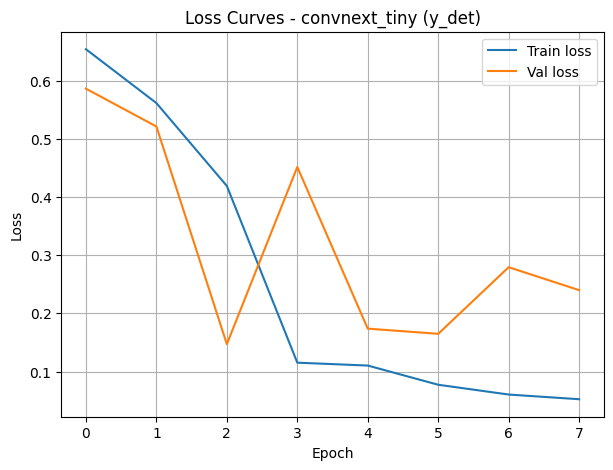


Classification Report:
              precision    recall  f1-score   support

     Not-AMD     0.9083    0.9909    0.9478       110
         AMD     0.9919    0.9173    0.9531       133

    accuracy                         0.9506       243
   macro avg     0.9501    0.9541    0.9505       243
weighted avg     0.9541    0.9506    0.9507       243



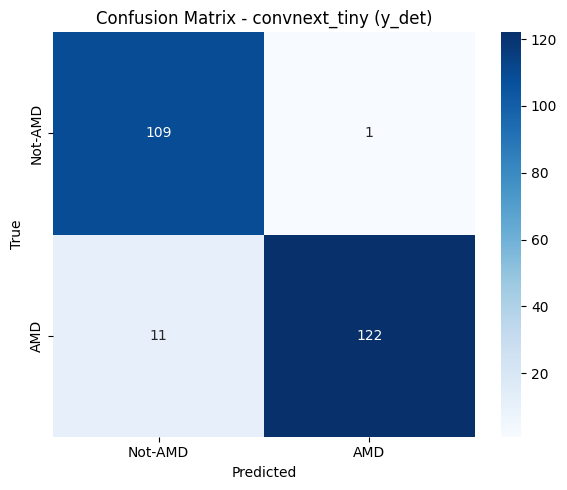

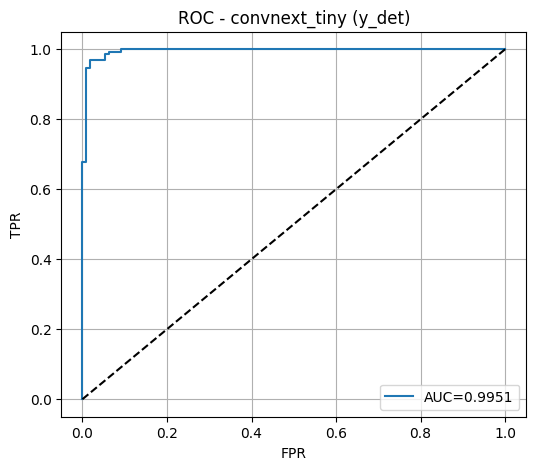

AUC: 0.9951469583048531
==== ConvNeXt-Small: AMD DETECTION ====

####################################################################################################
MODEL=convnext_small | TASK=y_det | img=224 | batch=32 | epochs=20
####################################################################################################
Train class counts: {0: 513, 1: 619}


Downloading: "https://download.pytorch.org/models/convnext_small-0c510722.pth" to /root/.cache/torch/hub/checkpoints/convnext_small-0c510722.pth
100%|██████████| 192M/192M [00:00<00:00, 222MB/s] 


Epoch 01/20 | train 0.6490 | val 0.5543


Epoch 02/20 | train 0.5318 | val 0.4981
Unfroze all layers. Fine-tune LR=0.0002


Epoch 03/20 | train 0.3132 | val 0.1563


...

Epoch 09/20 | train 0.0509 | val 0.1696


Epoch 10/20 | train 0.0580 | val 0.1714


Epoch 11/20 | train 0.0431 | val 0.3121


Epoch 12/20 | train 0.0613 | val 0.1880


Epoch 13/20 | train 0.0439 | val 0.2623
Early stopping at epoch 13. Best val loss: 0.1510


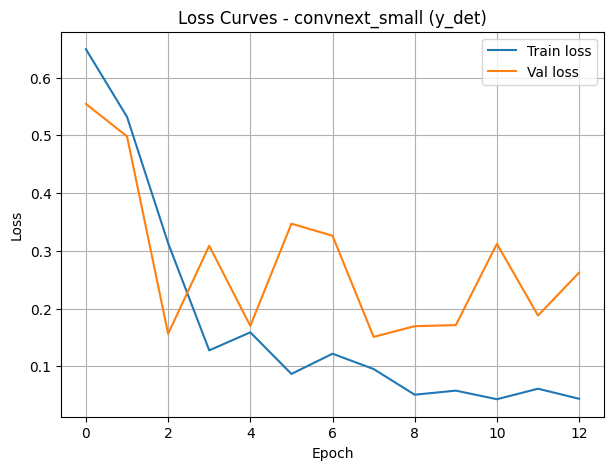


Classification Report:
              precision    recall  f1-score   support

     Not-AMD     0.9397    0.9909    0.9646       110
         AMD     0.9921    0.9474    0.9692       133

    accuracy                         0.9671       243
   macro avg     0.9659    0.9691    0.9669       243
weighted avg     0.9684    0.9671    0.9671       243



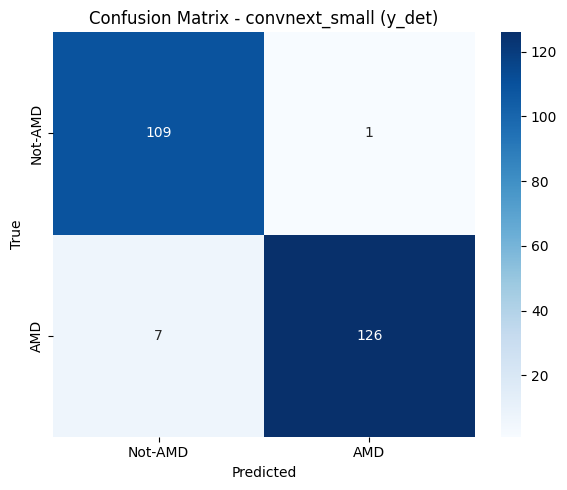

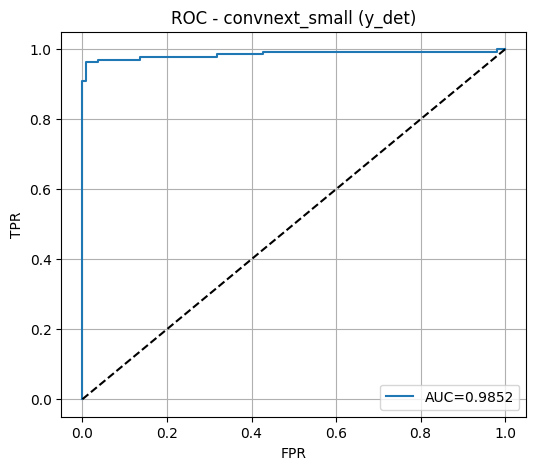

AUC: 0.985235816814764
==== EfficientNetV2-L: AMD DETECTION ====

####################################################################################################
MODEL=efficientnet_v2_l | TASK=y_det | img=320 | batch=2 | epochs=20
####################################################################################################
Train class counts: {0: 513, 1: 619}


Downloading: "https://download.pytorch.org/models/efficientnet_v2_l-59c71312.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_l-59c71312.pth
100%|██████████| 455M/455M [00:02<00:00, 192MB/s]  


Epoch 01/20 | train 0.7191 | val 0.6988


Epoch 02/20 | train 0.6395 | val 0.6170
Unfroze all layers. Fine-tune LR=5e-05


Epoch 03/20 | train 0.5001 | val 0.2682


...

Epoch 14/20 | train 0.0560 | val 0.4936


Epoch 15/20 | train 0.0494 | val 0.3139


Epoch 16/20 | train 0.0164 | val 0.3687


Epoch 17/20 | train 0.0779 | val 0.5718


Epoch 18/20 | train 0.1123 | val 0.3414
Early stopping at epoch 18. Best val loss: 0.2298


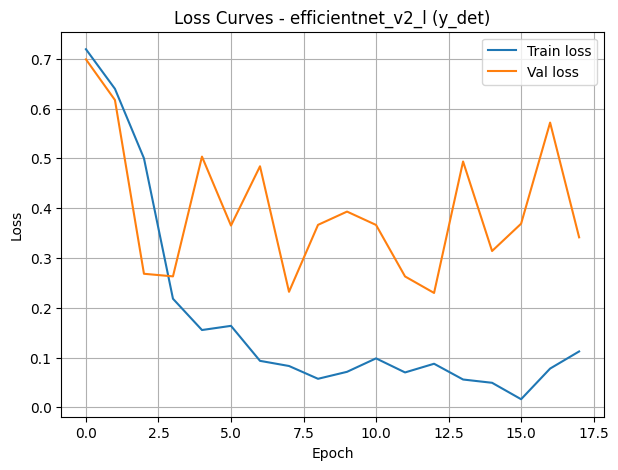


Classification Report:
              precision    recall  f1-score   support

     Not-AMD     0.9381    0.9636    0.9507       110
         AMD     0.9692    0.9474    0.9582       133

    accuracy                         0.9547       243
   macro avg     0.9536    0.9555    0.9544       243
weighted avg     0.9551    0.9547    0.9548       243



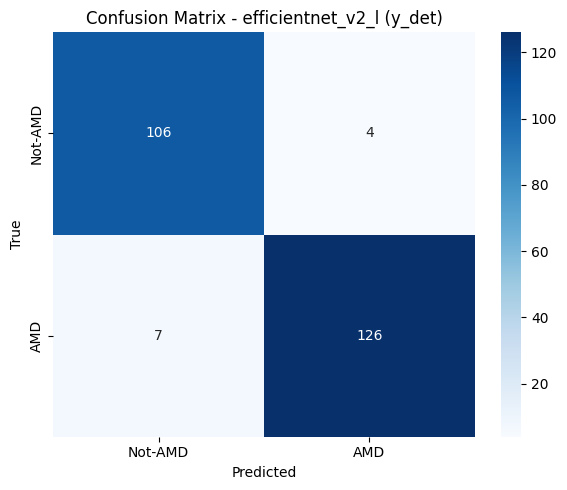

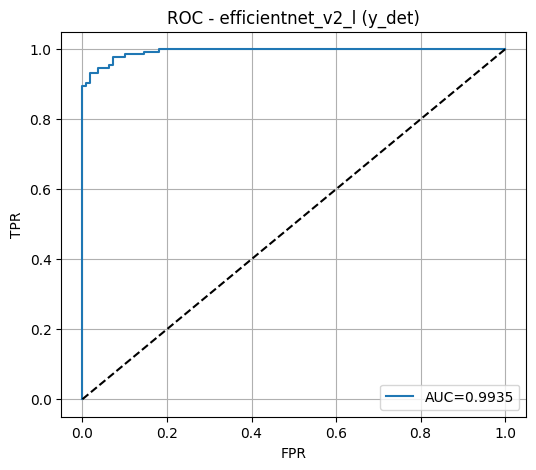

AUC: 0.9935064935064934


In [ ]:
print("==== ConvNeXt-Tiny: AMD DETECTION ====")
convnext_tiny_det = run_task(
    model_name="convnext_tiny",
    df_task=df_det,
    label_col="y_det",
    class_names=det_class_names,
    img_size=224,
    batch_size=64,   # try 64; if it fails, use 32
    epochs=20,
    freeze_epochs=2,
    patience=5
)

print("==== ConvNeXt-Small: AMD DETECTION ====")
convnext_small_det = run_task(
    model_name="convnext_small",
    df_task=df_det,
    label_col="y_det",
    class_names=det_class_names,
    img_size=224,
    batch_size=32,
    epochs=20,
    freeze_epochs=2,
    patience=5
)

print("==== EfficientNetV2-L: AMD DETECTION ====")
effv2l_det = run_task(
    model_name="efficientnet_v2_l",
    df_task=df_det,
    label_col="y_det",
    class_names=det_class_names,
    img_size=320,
    batch_size=2,    # try 4 if it fits
    epochs=20,
    freeze_epochs=2,
    patience=5
)

==== ConvNeXt-Tiny: AMD STAGING ====

####################################################################################################
MODEL=convnext_tiny | TASK=y_stage | img=224 | batch=64 | epochs=20
####################################################################################################
Train class counts: {0: 134, 1: 123, 2: 362}


Epoch 01/20 | train 1.0923 | val 1.0297


Epoch 02/20 | train 0.9896 | val 0.9447
Unfroze all layers. Fine-tune LR=0.0002


Epoch 03/20 | train 1.2134 | val 0.7161


Epoch 04/20 | train 0.4956 | val 0.4065


Epoch 05/20 | train 0.3135 | val 0.4969


Epoch 06/20 | train 0.1845 | val 0.4366


Epoch 07/20 | train 0.0936 | val 0.5400


Epoch 08/20 | train 0.0492 | val 0.8166


Epoch 09/20 | train 0.0978 | val 0.6871
Early stopping at epoch 9. Best val loss: 0.4065


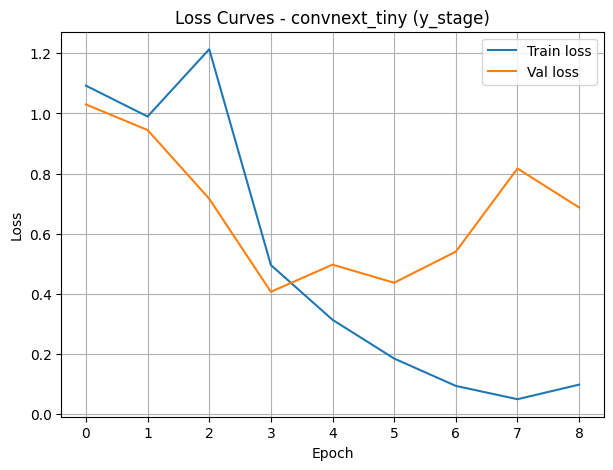


Classification Report:
              precision    recall  f1-score   support

       Early     0.6500    0.8966    0.7536        29
Intermediate     0.6667    0.4615    0.5455        26
        Late     0.9467    0.9103    0.9281        78

    accuracy                         0.8195       133
   macro avg     0.7544    0.7561    0.7424       133
weighted avg     0.8272    0.8195    0.8153       133



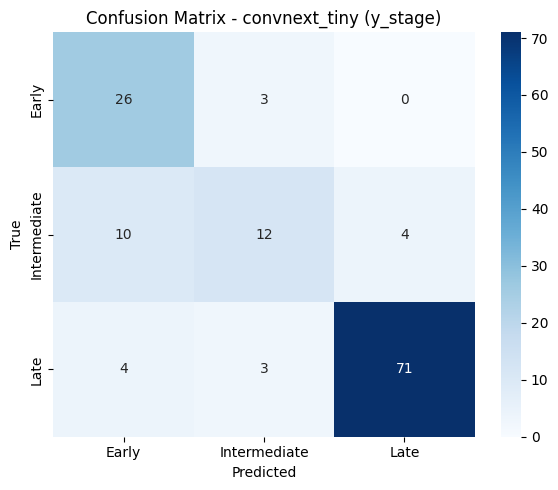

AUC macro OvR: 0.9385932567450453
AUC weighted OvR: 0.9546049498951614
==== ConvNeXt-Small: AMD STAGING ====

####################################################################################################
MODEL=convnext_small | TASK=y_stage | img=224 | batch=32 | epochs=20
####################################################################################################
Train class counts: {0: 134, 1: 123, 2: 362}


Epoch 01/20 | train 1.0403 | val 0.8972


Epoch 02/20 | train 0.9320 | val 0.8301
Unfroze all layers. Fine-tune LR=0.0002


Epoch 03/20 | train 0.8742 | val 0.5597


Epoch 04/20 | train 0.4884 | val 0.4152


Epoch 05/20 | train 0.3573 | val 0.6494


Epoch 06/20 | train 0.2135 | val 0.6464


Epoch 07/20 | train 0.2175 | val 0.4341


Epoch 08/20 | train 0.1755 | val 0.5700


Epoch 09/20 | train 0.0902 | val 0.7780
Early stopping at epoch 9. Best val loss: 0.4152


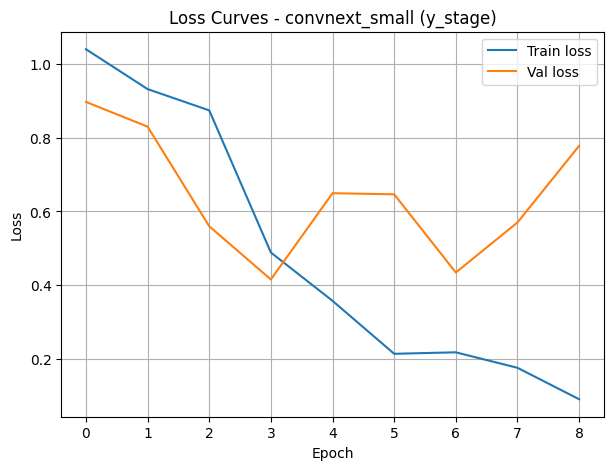


Classification Report:
              precision    recall  f1-score   support

       Early     0.9000    0.6207    0.7347        29
Intermediate     0.4528    0.9231    0.6076        26
        Late     1.0000    0.7692    0.8696        78

    accuracy                         0.7669       133
   macro avg     0.7843    0.7710    0.7373       133
weighted avg     0.8712    0.7669    0.7889       133



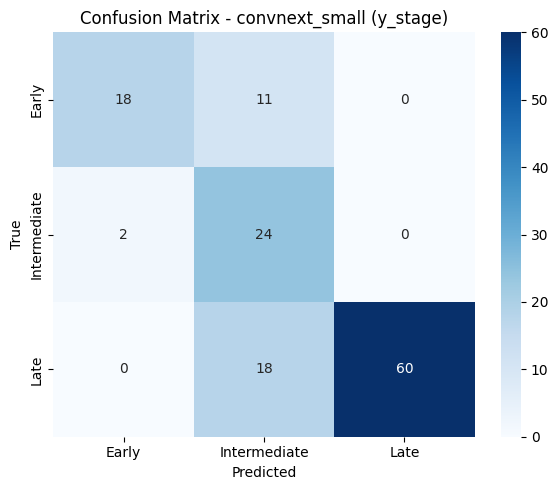

AUC macro OvR: 0.9484165948635818
AUC weighted OvR: 0.96000284761967
==== EfficientNetV2-L: AMD STAGING ====

####################################################################################################
MODEL=efficientnet_v2_l | TASK=y_stage | img=384 | batch=2 | epochs=20
####################################################################################################
Train class counts: {0: 134, 1: 123, 2: 362}


Epoch 01/20 | train 1.1164 | val 1.0684


Epoch 02/20 | train 1.0757 | val 0.9834
Unfroze all layers. Fine-tune LR=5e-05


Epoch 03/20 | train 0.8633 | val 0.3696


Epoch 04/20 | train 0.6359 | val 0.5991


Epoch 05/20 | train 0.4137 | val 0.6805


Epoch 06/20 | train 0.2685 | val 0.9428


Epoch 07/20 | train 0.2269 | val 0.9570


Epoch 08/20 | train 0.1944 | val 0.8613
Early stopping at epoch 8. Best val loss: 0.3696


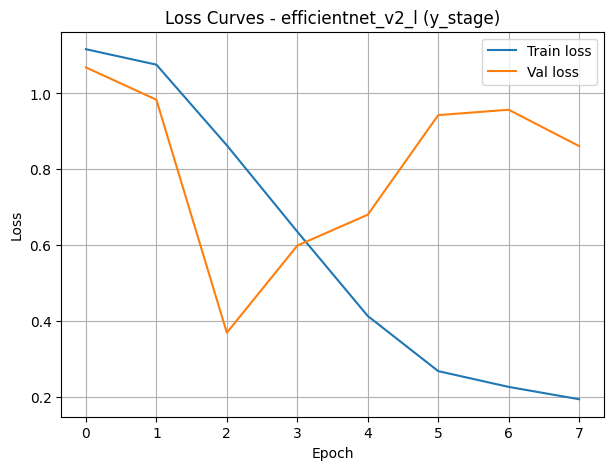


Classification Report:
              precision    recall  f1-score   support

       Early     0.6667    0.8966    0.7647        29
Intermediate     0.5714    0.6154    0.5926        26
        Late     0.9848    0.8333    0.9028        78

    accuracy                         0.8045       133
   macro avg     0.7410    0.7818    0.7534       133
weighted avg     0.8347    0.8045    0.8120       133



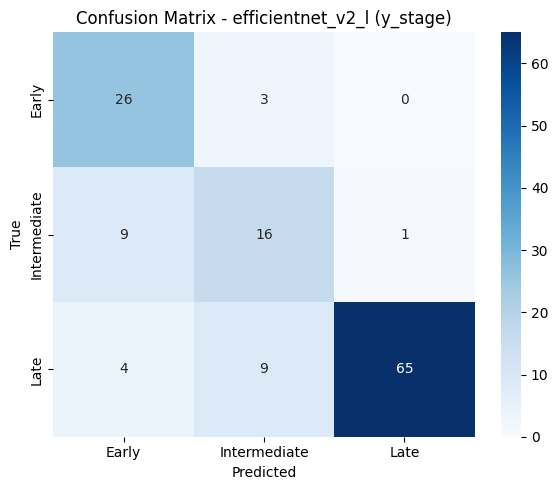

AUC macro OvR: 0.9080974473658973
AUC weighted OvR: 0.9320730671197962


In [ ]:
print("==== ConvNeXt-Tiny: AMD STAGING ====")
convnext_tiny_stage = run_task(
    model_name="convnext_tiny",
    df_task=df_stage,
    label_col="y_stage",
    class_names=stage_names,
    img_size=224,
    batch_size=64,
    epochs=20,
    freeze_epochs=2,
    patience=5
)

print("==== ConvNeXt-Small: AMD STAGING ====")
convnext_small_stage = run_task(
    model_name="convnext_small",
    df_task=df_stage,
    label_col="y_stage",
    class_names=stage_names,
    img_size=224,
    batch_size=32,
    epochs=20,
    freeze_epochs=2,
    patience=5
)

print("==== EfficientNetV2-L: AMD STAGING ====")
effv2l_stage = run_task(
    model_name="efficientnet_v2_l",
    df_task=df_stage,
    label_col="y_stage",
    class_names=stage_names,
    img_size=384,     # staging benefits from higher res
    batch_size=2,
    epochs=20,
    freeze_epochs=2,
    patience=5
)

In [ ]:
def detection_summary_row(model_name, out):
    y_true = out["y_true"]; y_pred = out["y_pred"]; probs = out["probs"]
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn + 1e-12)
    specificity = tn / (tn + fp + 1e-12)
    accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-12)
    precision_amd = tp / (tp + fp + 1e-12)
    f1_amd = 2 * precision_amd * sensitivity / (precision_amd + sensitivity + 1e-12)
    bal_acc = 0.5 * (sensitivity + specificity)
    auc_val = roc_auc_score(y_true, probs[:, 1])
    return {
        "model": model_name,
        "Accuracy": accuracy,
        "Sensitivity (Recall AMD)": sensitivity,
        "Specificity": specificity,
        "Precision (PPV AMD)": precision_amd,
        "F1 (AMD)": f1_amd,
        "Balanced Accuracy": bal_acc,
        "AUC": auc_val,
        "Test N (Not-AMD)": int((np.asarray(y_true) == 0).sum()),
        "Test N (AMD)": int((np.asarray(y_true) == 1).sum()),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }

def staging_summary_row(model_name, out, stage_names):
    y_true = np.asarray(out["y_true"]); y_pred = np.asarray(out["y_pred"]); probs = np.asarray(out["probs"])
    n = len(stage_names)

    row = {
        "model": model_name,
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Macro AUC (OvR)": roc_auc_score(y_true, probs, multi_class="ovr", average="macro"),
    }

    cm = confusion_matrix(y_true, y_pred, labels=list(range(n)))
    y_bin = label_binarize(y_true, classes=list(range(n)))

    for i, name in enumerate(stage_names):
        # recall per stage
        row_sum = cm[i, :].sum()
        row[f"Recall {name}"] = (cm[i, i] / (row_sum + 1e-12)) if row_sum > 0 else np.nan

        # per-stage AUC
        if y_bin[:, i].sum() == 0 or y_bin[:, i].sum() == len(y_bin):
            row[f"AUC {name} (OvR)"] = np.nan
        else:
            row[f"AUC {name} (OvR)"] = roc_auc_score(y_bin[:, i], probs[:, i])

        # supports
        row[f"Test N ({name})"] = int((y_true == i).sum())

    return row

det_summary = pd.DataFrame([
    detection_summary_row("ConvNeXt-Tiny", convnext_tiny_det),
    detection_summary_row("ConvNeXt-Small", convnext_small_det),
    detection_summary_row("EfficientNetV2-L", effv2l_det),
])
display(det_summary)

stage_summary = pd.DataFrame([
    staging_summary_row("ConvNeXt-Tiny", convnext_tiny_stage, stage_names),
    staging_summary_row("ConvNeXt-Small", convnext_small_stage, stage_names),
    staging_summary_row("EfficientNetV2-L", effv2l_stage, stage_names),
])
display(stage_summary)

,model,Accuracy,Sensitivity (Recall AMD),Specificity,Precision (PPV AMD),F1 (AMD),Balanced Accuracy,AUC,Test N (Not-AMD),Test N (AMD),TN,FP,FN,TP
0,ConvNeXt-Tiny,0.950617,0.917293,0.990909,0.991870,0.953125,0.954101,0.995147,110,133,109,1,11,122
1,ConvNeXt-Small,0.967078,0.947368,0.990909,0.992126,0.969231,0.969139,0.985236,110,133,109,1,7,126
2,EfficientNetV2-L,0.954733,0.947368,0.963636,0.969231,0.958175,0.955502,0.993506,110,133,106,4,7,126


,model,Macro Precision,Macro Recall,Macro F1,Weighted F1,Balanced Accuracy,Macro AUC (OvR),Recall Early,AUC Early (OvR),Test N (Early),Recall Intermediate,AUC Intermediate (OvR),Test N (Intermediate),Recall Late,AUC Late (OvR),Test N (Late)
0,ConvNeXt-Tiny,0.754444,0.756116,0.742394,0.815256,0.756116,0.938593,0.896552,0.963859,29,0.461538,0.873832,26,0.910256,0.978089,78
1,ConvNeXt-Small,0.784277,0.770999,0.737285,0.788945,0.770999,0.948417,0.620690,0.959881,29,0.923077,0.907980,26,0.769231,0.977389,78
2,EfficientNetV2-L,0.740981,0.781757,0.753359,0.812034,0.781757,0.908097,0.896552,0.939655,29,0.615385,0.817038,26,0.833333,0.967599,78


In [ ]:
os.listdir("/kaggle/input")

['octdl-for-image-based-deep-learning-methods']